In [5]:
%cd ..
from experiment_control.srs_microscope.srs_microscope import *

c:\Users
Opening connnection to Keithley source meter
Opening connection to Agilent E3633A DC Power Supply
VOA initialized to 4.99 volt


# Plot Galvo scan

In [37]:
d_spot = 0.9*u.um
N = 150
Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot)
print(np.max(ds0['x']) - np.min(ds0['x']))
print((np.max(ds0['x']) - np.min(ds0['x']))/N)
print(np.max(ds0['t']))


scan volt: 0.3872813366541991 volt
scan length: 67.5 micrometer
75.0 micrometer
0.5 micrometer
11.25 second


loading file: GalvoScan_diamond_OEland1074.4-73mW_100uV300us_N150V_6tlia_dspot1um_2025-11-02-20-44-00.h5
importing Dev1...
importing Vsrs_g...
importing Vx...
importing Vy...
importing laser_spot_img...
importing t...
importing wf_img...
importing x...
importing x_img...
importing y...
importing y_img...
importing attr Vx0...
volt
importing attr Vx0_units...
importing attr Vy0...
volt
importing attr Vy0_units...
importing attr dx_dVx...
micrometer / volt
importing attr dx_dVx_units...
importing attr dx_dpix...
micrometer
importing attr dx_dpix_units...
importing attr dy_dVy...
micrometer / volt
importing attr dy_dVy_units...


c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


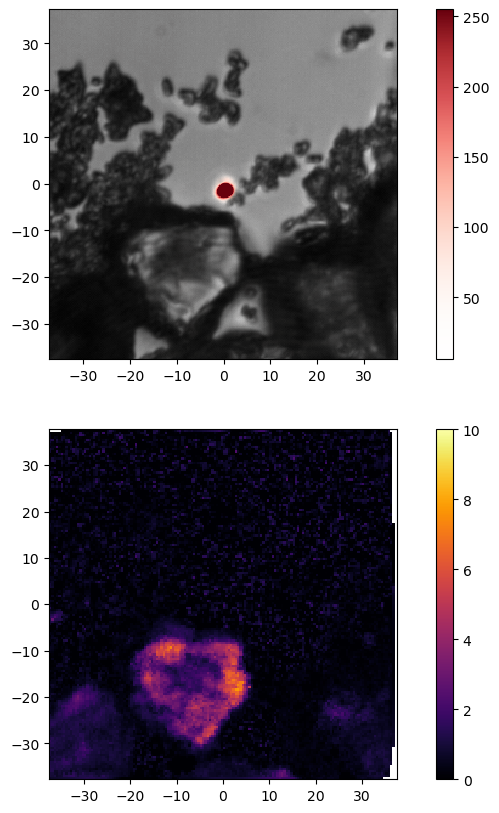

In [507]:
fname = "GalvoScan_diamond_OEland1074.4-73mW_100uV300us_N150V_6tlia_dspot1um_2025-11-02-20-44-00.h5"
dir_name =  "Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04"

fpath=os.path.join(data_dir, dir_name)
ds0=load_data_from_file(fpath, fname)

%matplotlib inline
fig = plot_scan_data(ds0, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=10)

C:\Users\euyehara\AppData\Local\Temp\ipykernel_58040\2119115023.py:19: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  temp[row,:] = copy.deepcopy(Vsrs_2d[row,:][:])
C:\Users\euyehara\AppData\Local\Temp\ipykernel_58040\2119115023.py:17: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  temp[row,1:] = copy.deepcopy(Vsrs_2d[row,::-1][:-1])


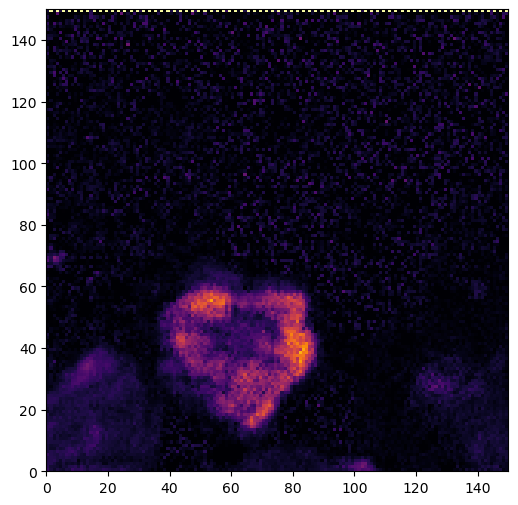

In [506]:
# import copy
# No interpolation

%matplotlib inline

# import copy
def unwrap_scan(Vsrs_1d, nx, ny):
    """
    Unwrap 1d array of raster values into (2d (nx,ny) array) without interpolation
    """
  
    Vsrs_2d = np.reshape(Vsrs_1d, (nx, ny))
    temp = np.ones((nx, ny))*10
    for row in range(Vsrs_2d.shape[0]):
        if row %2 != 0: #odd
            # Vsrs_2d[row,:] = Vsrs_2d[row,::-1]
            temp[row,1:] = copy.deepcopy(Vsrs_2d[row,::-1][:-1])
        else:
            temp[row,:] = copy.deepcopy(Vsrs_2d[row,:][:])
    return temp

nx = 150
ny = nx

Vsrs = ds0["Dev1"]["ai0"][1:]
data2 = unwrap_scan(Vsrs, nx, ny)
# data2 = np.reshape(Vsrs, (nx, ny))

fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.pcolormesh(np.flipud(data2.T), vmin=0, vmax=10, cmap=cm.inferno)
ax.set_aspect("equal")



# Plot Single Point spectrum

loading file: Spectra_diamond_FFP-I_60dB_0.5nmStep_100us1mV_2025-11-02-18-42-48.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...
Calib Peak at 1336.234 / centimeter
Uncal Peak at 1336.234 / centimeter


C:\Users\euyehara\AppData\Local\Temp\ipykernel_58040\3562465475.py:117: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]
c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


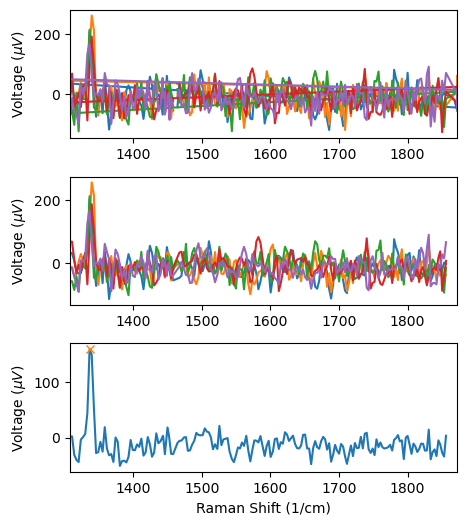

In [142]:
%matplotlib inline
fpath = os.path.join(data_dir,"Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04")
fname = "Spectra_diamond_FFP-I_60dB_0.5nmStep_100us1mV_2025-11-02-18-42-48.h5"
ds0 = load_data_from_file(fpath, fname)

# wavvolt_test = os.path.join(calib_dir, "wavvolt_dev1b_15C_CW976_boa_0.00mW_2025-10-11_FIXED2.mat") #For wavelength set

savepath = None
fname = None
fig = plot_daq_sweepSpectra(ds0, wavvolt_HVCALIB=wavvolt_HVCALIB)
# fig = plot_daq_sweepSpectra(ds0, savefig=False, fname=None, fpath=None, wavvolt_HVCALIB=wavvolt_file)


# Plot Raw Hyperspectral Image

In [163]:
d_spot = 1.2*u.um
N = 150
Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot)
print(np.max(ds['x']) - np.min(ds['x']))
print((np.max(ds['x']) - np.min(ds['x']))/N)
# print(np.max(ds0['t']))

scan volt: 0.5163751155389321 volt
scan length: 90.0 micrometer
90.0 micrometer
0.6 micrometer


loading file: HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23.h5
importing Dev1...
importing Dev2...
importing HV_g...
importing HV_pix...
importing VCSEL_wavmon_g...
importing VCSEL_wavmon_pix...
importing Vsrs_g...
importing Vsrs_pix...
importing Vx...
importing Vy...
importing laser_spot_img...
importing raman_shift...
importing t...
importing t_scan...
importing t_sweep...
importing wavelength_set...
importing wavset_sort...
importing wf_img...
importing x...
importing x_img...
importing y...
importing y_img...
importing attr Vx0...
volt
importing attr Vx0_units...
importing attr Vy0...
volt
importing attr Vy0_units...
importing attr dx_dVx...
micrometer / volt
importing attr dx_dVx_units...
importing attr dx_dpix...
micrometer
importing attr dx_dpix_units...
importing attr dy_dVy...
micrometer / volt
importing attr dy_dVy_units...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_l

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


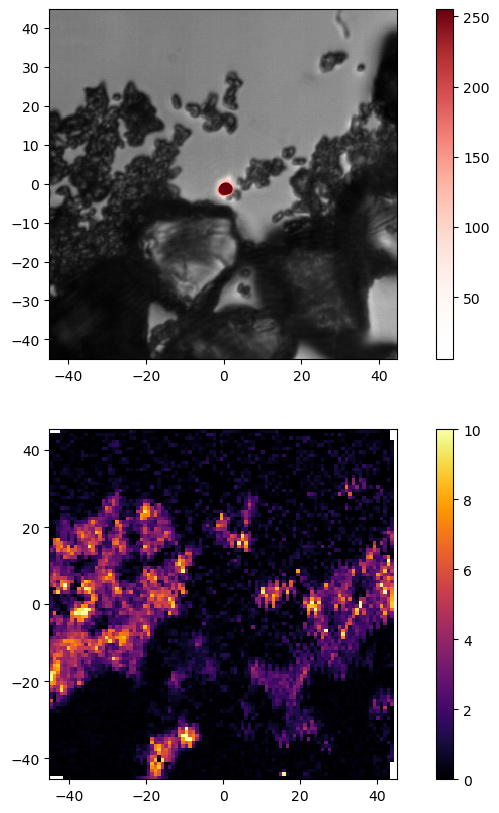

In [735]:
fpath = os.path.join(data_dir, "Sample_GSdev1b_hyperspectral_image_2025-11-02-19-20-23")
fname = "HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23"
 
ds = load_data_from_file(fpath, fname + ".h5")
Vsrs_hs = xr.open_dataarray(os.path.join(fpath, fname + ".nc"))

%matplotlib inline
wavnum = 1511/ u.cm
fig = plot_hyperspectral_scan(ds, Vsrs_hs, wavnum, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=10, wf_offsets=None, plot_wf=True)

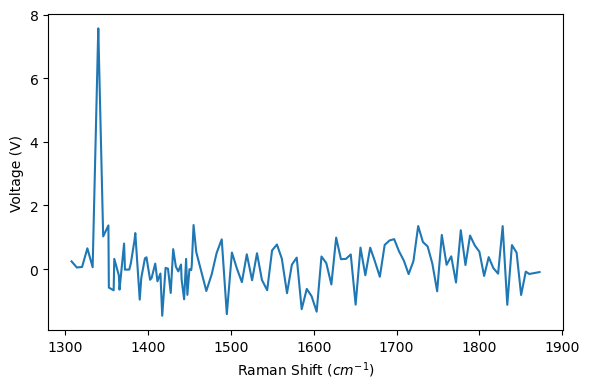

In [230]:
%matplotlib inline

x=2
y=-16

fig = plot_pixel_spec(Vsrs_hs, x=x, y=y)

In [525]:
# ds['sens_lia']
d_spot = 1.8*u.um
N = 100
Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot)
print(np.max(ds['x']) - np.min(ds['x']))
print((np.max(ds['x']) - np.min(ds['x']))/N)


scan volt: 0.5163751155389321 volt
scan length: 90.0 micrometer
90.0 micrometer
0.9 micrometer


In [ ]:
# From process_hyperspectral_scan
# Fix bug in galvo unwrapping in 1st 3 datasets
# save reprocessed data in new hdf5 file

"""
Parses sweep_read_data and scan_read_data dicts into a 3d array of wavelength scans at each pixel.
Creates meshgrids of set Vx and Vy write scan voltages and interpolates Vsrs data AT EACH WAVELENGTH at these points from measured Vx and Vy.
Notes: 
    - HV to wavelength calibration not performed here, but necessary datasets for calibration saved in proc_data
    - Assumes single sweep per pixel - better to increase SNR by increasing t_lia (see versions before 10/25/25 for unwrapping multiple sweeps per pixel)
:return: proc_data: dictionary of processed data, with image data stored in an xarray
"""
t_scan = ds["t_scan"]
t_sweep = ds["t_sweep"]
pad = 5
offset = 0
nx = ds['Vsrs_g'].shape[0]
ny = ds['Vsrs_g'].shape[1]

# d_spot = 1.8*u.um
# N = nx
# Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot)
pad_galvo_endpts = 1
fixed_wav = 1074.4 * u.nm

ΔVx = 0.516*u.V
ΔVy = ΔVx

#Sort wavelength by ascending order and remove repeated values
# s_ind = np.argsort(wavelength_set)
# wavset_sort = wavelength_set[s_ind]
wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
wavset_sort = wavset_sort * u.nm

Vsrs_raw = ds['Dev2']['ai0']
HV_raw = Vmon_to_HVA(ds['Dev2']['ai1'])
VCSEL_wavmon_raw = ds['Dev2']['ai3']

#Remove padded samples at endpoints of daq2 arrays
Vsrs_raw = Vsrs_raw[pad:-pad]
HV_raw = HV_raw[pad:-pad]
VCSEL_wavmon_raw = VCSEL_wavmon_raw[pad:-pad]

#Reshape into 2d array with n_pix rows
num_pix = nx*ny 
npix = num_pix + 1
N_wav = Vsrs_raw.shape[0] // npix
N_unqwav = s_ind.shape[0]

print(f"npix: {npix}")
print(f"Vsrs_raw.shape[0]: {Vsrs_raw.shape[0]}")
print(f"N_wav: {N_wav}")
print(f"N_unqwav: {N_unqwav}")

Vsrs_pix = np.reshape(np.array(Vsrs_raw.to(u.V).m), (npix, N_wav))
HV_pix = np.reshape(np.array(HV_raw.to(u.V).m), (npix, N_wav))
VCSEL_wavmon_pix = np.reshape(np.array(VCSEL_wavmon_raw.to(u.V).m), (npix, N_wav))

#Discard 1st pixel sweep (first row) - galvo ai reads garbage here
#Discard pad_galvo_endpts points from the start of each row - vcsel ai lags ao
Vsrs_pix = Vsrs_pix[:-1,pad_galvo_endpts:]
HV_pix = HV_pix[:-1,pad_galvo_endpts:] 
VCSEL_wavmon_pix = VCSEL_wavmon_pix[:-1,pad_galvo_endpts:]


# Initialize arrays for pixel x spectra with sorted, unique spectral points
Vsrs_unqpix = np.zeros((num_pix, N_unqwav))
HV_unqpix = np.zeros((num_pix, N_unqwav))
VCSEL_wavmon_unqpix = np.zeros((num_pix, N_unqwav))

#Odd pixels are backward sweeps - flip (Assumes only 1 num_sweeps per pix is 1)
for row in range(Vsrs_pix.shape[0]):
    if row % 2 != 0:
        Vsrs_pix[row,:] = Vsrs_pix[row,::-1]
        HV_pix[row,:] = HV_pix[row,::-1]
        VCSEL_wavmon_pix[row,:] = VCSEL_wavmon_pix[row,::-1]
    # Sort columns (wavelength sweep) by ascending order and remove repeated values
    Vsrs_unqpix[row,:] = Vsrs_pix[row, s_ind]
    HV_unqpix[row,:] = HV_pix[row, s_ind]
    VCSEL_wavmon_unqpix[row,:] = VCSEL_wavmon_pix[row, s_ind]
    
#Interpolate each wavelength to measured pixel grid
Vx_meas = ds['Dev1']['ai2'][1:] #discard 1st ai value (ai lags ao by 1 sample point)
Vy_meas = ds['Dev1']['ai3'][1:] #discard 1st ai value (ai lags ao by 1 sample point)

Vx,Vy = scan_vals(nx,ny,ΔVx,ΔVy,Vx0,Vy0)
Vx_g, Vy_g = np.meshgrid(Vx.m,Vy.m)

Vsrs_g = np.zeros((nx, ny, N_unqwav))
HV_g = np.zeros((nx, ny, N_unqwav))
VCSEL_wavmon_g = np.zeros((nx, ny, N_unqwav))

for hvind in range(Vsrs_unqpix.shape[1]):
    Vsrs_g[:,:, hvind] = griddata((Vx_meas.m, Vy_meas.m), Vsrs_unqpix[:, hvind], (Vx_g, Vy_g)) * u.volt
    #No interpolation necessary for HV, use griddata to reshape array
    HV_g[:,:, hvind] = unwrap_scan(HV_unqpix[:,hvind], nx, ny) * u.volt
    VCSEL_wavmon_g[:,:,hvind] = unwrap_scan(VCSEL_wavmon_unqpix[:,hvind], nx, ny) * u.volt
    
x = ((Vx-Vx0)*dx_dVx).to(u.um)
y = ((Vy-Vy0)*dy_dVy).to(u.um)

#Convert wavelength_set to wavenumber
raman_shift = (1/fixed_wav - 1/wavset_sort).to(1/u.cm)

#Store hs-image into xarray
Vsrs_hs = hs_xarray(data=Vsrs_g, x=x, y=y, raman_shift=raman_shift)
    # HV_hs = hs_xarray(data=HV_g, x=x, y=y, wavelength=wavelength_set, raman_shift=raman_shift)
    
# Store hs-image data and additional info into proc_data dict
proc_data = {
    "Vx"                : Vx,
    "Vy"                : Vy,
    "dx_dVx"            : dx_dVx,
    "dy_dVy"            : dy_dVy,
    "x"                 : x,
    "y"                 : y,
    "Vsrs_pix"          : Vsrs_unqpix,
    "HV_pix"            : HV_unqpix,
    "VCSEL_wavmon_pix"  : VCSEL_wavmon_unqpix,
    "Vsrs_g"            : Vsrs_g,
    "raman_shift"       : raman_shift,
    "wavset_sort"       : wavset_sort,
    "HV_g"              : HV_g,
    "VCSEL_wavmon_g"    : VCSEL_wavmon_g,
    "t_scan"            : t_scan,
    "t_sweep"           : t_sweep
}

# return proc_data, Vsrs_hs

npix: 10001
Vsrs_raw.shape[0]: 2000200
N_wav: 200
N_unqwav: 190


C:\Users\euyehara\AppData\Local\Temp\ipykernel_58040\567719178.py:94: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  Vsrs_g[:,:, hvind] = griddata((Vx_meas.m, Vy_meas.m), Vsrs_unqpix[:, hvind], (Vx_g, Vy_g)) * u.volt
C:\Users\euyehara\AppData\Local\Temp\ipykernel_58040\567719178.py:96: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  HV_g[:,:, hvind] = unwrap_scan(HV_unqpix[:,hvind], nx, ny) * u.volt
C:\Users\euyehara\AppData\Local\Temp\ipykernel_58040\567719178.py:97: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  VCSEL_wavmon_g[:,:,hvind] = unwrap_scan(VCSEL_wavmon_unqpix[:,hvind], nx, ny) * u.volt


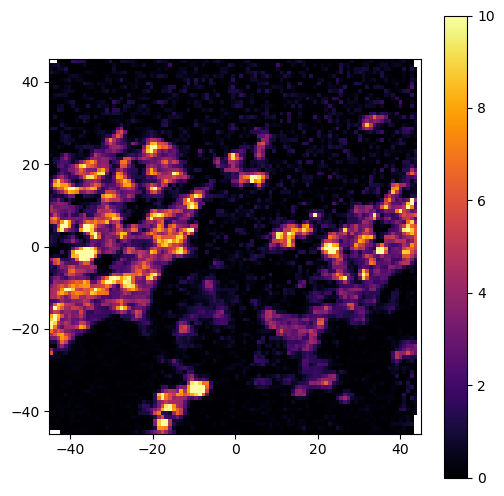

In [737]:
# print(ds['Vsrs_g'].shape)
# from copy import deepcopy
%matplotlib inline

wavnum = 1513/ u.cm

Vsrs_2d = np.asarray(Vsrs_hs.sel(raman_shift=wavnum, method="nearest")) 

fig, ax = plt.subplots(1,1,figsize=(6,6))
p0 = ax.pcolormesh(Vsrs_hs["y"], Vsrs_hs["x"], np.flipud(np.transpose(Vsrs_2d)), cmap=cm.inferno, vmin=0, vmax=10)
cb1 = plt.colorbar(p0, ax=ax)
ax.set_aspect("equal")

In [738]:
sample_dir = "GSdev1b_hyperspectral_image_2025-11-02-19-20-23"
resave_fname = "HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23_FIXGALVO"
# ds = load_data_from_file(fpath, fname + ".h5")
# Vsrs_hs = xr.open_dataarray(os.path.join(fpath, fname + ".nc"))
sample_dir = resolve_sample_dir(sample_dir, data_dir=data_dir)

fpath = new_path(name=resave_fname,data_dir=sample_dir,ds_type='HyperspecImg',extension='h5',timestamp=True)
xrpath = new_path(name=resave_fname,data_dir=sample_dir,ds_type='HyperspecImg',extension='nc',timestamp=True)
print("saving data to: ")
print(fpath)
print(xrpath)

dump_hdf5(
    {   'wf_img': ds["wf_img"],
        'laser_spot_img': ds["laser_spot_img"],
        'dx_dpix': ds["dx_dpix"],
        'x_img': ds["x_img"],
        'y_img': ds["y_img"],
        "dx_dVx" : ds["dx_dVx"],
        "dy_dVy" : ds["dy_dVy"],
        "Vx0" : ds["Vx0"],
        "Vy0" : ds["Vy0"],
        'num_sweep': ds["num_sweep"],
        't_lia': ds["t_lia"],
        'sens_lia': ds["sens_lia"],
        'wav_start': ds["wav_start"],
        'wav_stop': ds["wav_stop"],
        'Δwav': ds["Δwav"],
        'wavelength_set': ds["wavelength_set"],  # Sorted by increasing voltage (same as HV_set)
        'pump_wav': ds["pump_wav"]
    },
    fpath,
    open_mode='x',
    )

dump_hdf5(proc_data, fpath)
ds2 = load_hdf5(fpath=fpath)
Vsrs_hs.to_netcdf(xrpath)


saving data to: 
C:\Users\euyehara\OneDrive\Documents\data\srs_microscope\Sample_GSdev1b_hyperspectral_image_2025-11-02-19-20-23\HyperspecImg_HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23_FIXGALVO_2025-11-05-18-29-06.h5
C:\Users\euyehara\OneDrive\Documents\data\srs_microscope\Sample_GSdev1b_hyperspectral_image_2025-11-02-19-20-23\HyperspecImg_HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23_FIXGALVO_2025-11-05-18-29-06.nc
dumping item: wf_img
dumping item: laser_spot_img
dumping item: dx_dpix
non-array, non-list item with units:
micrometer
dumping item: x_img
dumping item: y_img
dumping item: dx_dVx
non-array, non-list item with units:
micrometer / volt
dumping item: dy_dVy
non-array, non-list item with units:
micrometer / volt
dumping item: Vx0
non-array, non-list item with units:
volt
dumping item: Vy0
non-array, non-list item with units:
volt
dumping item: num_sweep
non-array, non-list item without units
dumping item

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


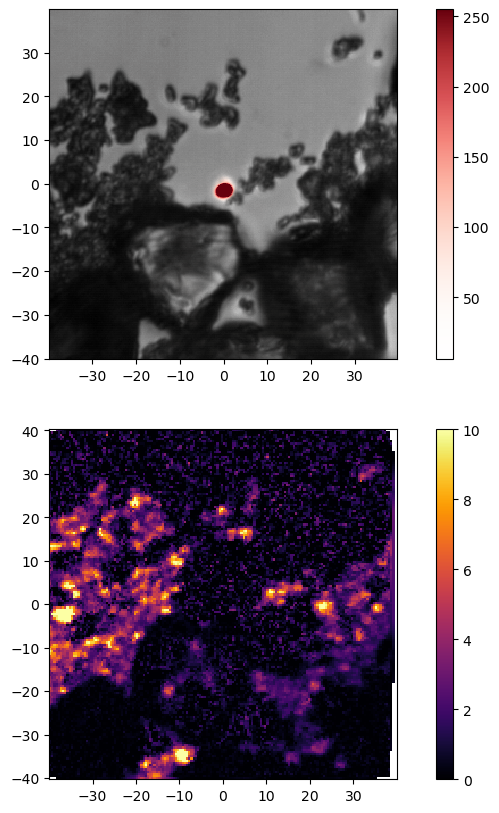

In [734]:
%matplotlib inline
wavnum = 1511/ u.cm
fig = plot_hyperspectral_scan(ds2, Vsrs_hs, wavnum, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=10, wf_offsets=None, plot_wf=True)

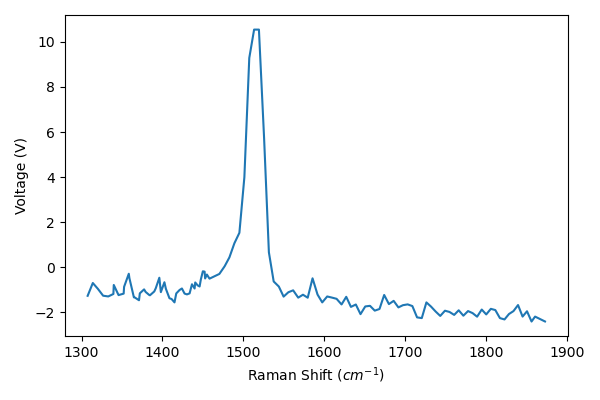

In [662]:
x=-10
y=-33

%matplotlib widget
fig = plot_pixel_spec(Vsrs_hs, x=x, y=y)

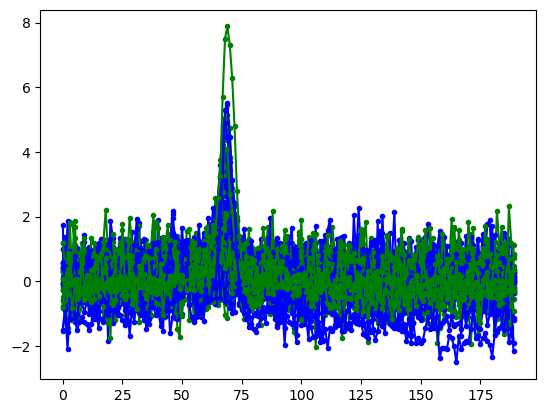

In [739]:
plt.figure()
# for row in range(Vsrs_pix.shape[0]):
for row in range(30,70):
    if row %2 == 0:
        plt.plot(ds2["Vsrs_pix"][row], '.-', color='b')
        # plt.plot(Vsrs_unqpix[row], '.-', color='b')
    else:
        plt.plot(ds2["Vsrs_pix"][row], '.-', color='g')
        # plt.plot(Vsrs_unqpix[row], '.-', color='g')

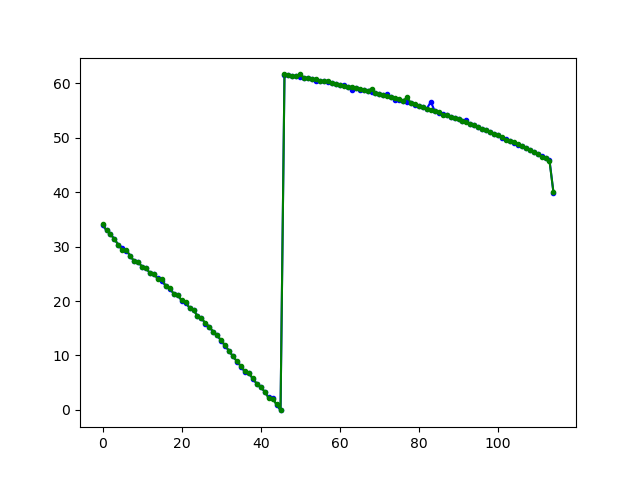

In [ ]:

plt.figure()
# for row in range(Vsrs_pix.shape[0]):
for row in range(30,32):
    if row %2 == 0:
        plt.plot(ds["HV_pix"][row], '.-', color='b')
    else:
        plt.plot(ds["HV_pix"][row], '.-', color='g')

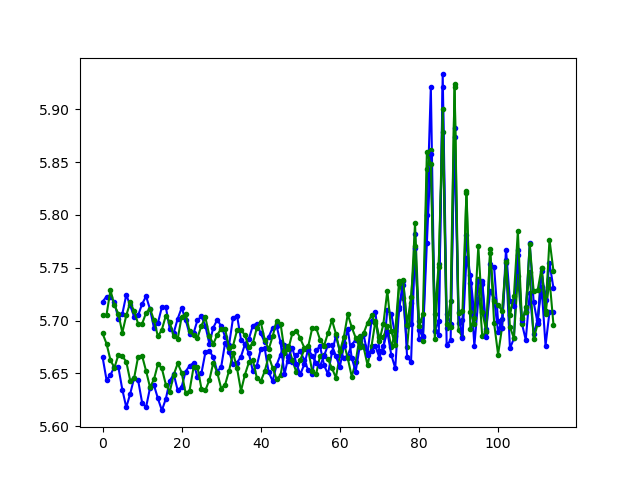

In [351]:
plt.figure()
# for row in range(Vsrs_pix.shape[0]):
for row in range(30,34):
    if row %2 == 0:
        plt.plot(ds["VCSEL_wavmon_pix"][row], '.-', color='b')
    else:
        plt.plot(ds["VCSEL_wavmon_pix"][row], '.-', color='g')

In [598]:
# import copy
def unwrap_scan(Vsrs_1d, nx, ny):
    """
    Unwrap 1d array of raster values into (2d (nx,ny) array) without interpolation
    """
    Vsrs_2d = np.reshape(Vsrs_1d, (nx, ny))
    Vsrs = copy.deepcopy(Vsrs_2d)
    for row in range(Vsrs_2d.shape[0]):
        if row %2 != 0: #odd
            Vsrs[row,:] = Vsrs_2d[row,::-1]
    return Vsrs

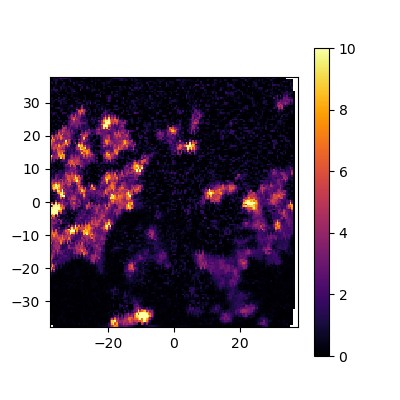

In [307]:
wavnum = 1516/ u.cm
fig = plot_hyperspectral_scan(ds, Vsrs_hs, wavnum, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=10, wf_offsets=None, plot_wf=False)


# Calibrate Wavelength

## Using FFP peaks

In [27]:
fpath = os.path.join(calib_dir,'FFP-I_peaks')
FFP_cal_pks = load_hdf5(fpath=fpath)


loading file: FFP-I_peaks
importing peaks...


loading file: HyperspecImg_Nikon20x_N150_CaroteneDiamond_1nm_300us_85min_6tlia_12dbdec_2025-11-02-22-00-59.h5
importing Dev1...
importing Dev2...
importing HV_g...
importing HV_pix...
importing VCSEL_wavmon_g...
importing VCSEL_wavmon_pix...
importing Vsrs_g...
importing Vsrs_pix...
importing Vx...
importing Vy...
importing laser_spot_img...
importing raman_shift...
importing t...
importing t_scan...
importing t_sweep...
importing wavelength_set...
importing wavset_sort...
importing wf_img...
importing x...
importing x_img...
importing y...
importing y_img...
importing attr Vx0...
volt
importing attr Vx0_units...
importing attr Vy0...
volt
importing attr Vy0_units...
importing attr dx_dVx...
micrometer / volt
importing attr dx_dVx_units...
importing attr dx_dpix...
micrometer
importing attr dx_dpix_units...
importing attr dy_dVy...
micrometer / volt
importing attr dy_dVy_units...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing

In [76]:
dir_name = "Sample_GSdev1b_hyperspectral_image_2025-11-02-19-20-23"
fname ="HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23_FIXGALVO_2025-11-05-18-29-06.h5"
# fname = "HyperspecImg_Nikon20x_N150_CaroteneDiamond_1nm_300us_85min_6tlia_12dbdec_2025-11-02-22-00-59.h5"
fpath = os.path.join(data_dir, dir_name)
ds = load_data_from_file(fpath, fname)

fig, ax = plot_daqsweep_wavmon(ds, id_sweep_dir=True, ds_type='hs_image', colors=['b','g'], ax=ax)


loading file: HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23_FIXGALVO_2025-11-05-18-29-06.h5
importing HV_g...
importing HV_pix...
importing VCSEL_wavmon_g...
importing VCSEL_wavmon_pix...
importing Vsrs_g...
importing Vsrs_pix...
importing Vx...
importing Vy...
importing laser_spot_img...
importing raman_shift...
importing t_scan...
importing t_sweep...
importing wavelength_set...
importing wavset_sort...
importing wf_img...
importing x...
importing x_img...
importing y...
importing y_img...
importing attr Vx0...
volt
importing attr Vx0_units...
importing attr Vy0...
volt
importing attr Vy0_units...
importing attr dx_dVx...
micrometer / volt
importing attr dx_dVx_units...
importing attr dx_dpix...
micrometer
importing attr dx_dpix_units...
importing attr dy_dVy...
micrometer / volt
importing attr dy_dVy_units...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
import

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


In [73]:
def plot_daqsweep_wavmon(ds, ds_type='sweep', id_sweep_dir=False, colors=['b','g'], ax=None, fig=None):
    """
    ds_type: 'sweep': single point daq sweeps, 'hs_im': hyperspectral image
    """
    #Load FFP peaks from calibration file
    fpath = os.path.join(calib_dir,'FFP-I_peaks')
    FFP_cal_pks = load_hdf5(fpath=fpath)
    cal_pks = FFP_cal_pks["peaks"]
    
    
    #restrict FFP_cal_pks to tuning range
    FFP_cal = cal_pks[(cal_pks >= np.nanmin(ds['wavelength_set'])) & (cal_pks <= np.nanmax(ds['wavelength_set']))] 
    FFP_cal = FFP_cal[~((FFP_cal > ds['wavelength_set'][0]) & (FFP_cal < ds['wavelength_set'][-1]))]

    if ds_type == 'sweep':
        wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
        wavset_sort = wavset_sort * u.nm
        wavmon_arr = ds["VCSEL_wavmon_arr"][:, s_ind]
    elif ds_type == 'hs_image':
        wavset_sort = ds["wavset_sort"]
        wavmon_arr = ds["VCSEL_wavmon_pix"]
    else:
        raise ValueError("Specify ds_type='hs_image' or 'sweep'")
    #Plotting
    even_color = colors[0]
    odd_color = even_color
    if id_sweep_dir:
        odd_color=colors[1]
    
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
        
    # for row in range(4):
    #     if row %2 != 0:
    #         ax.plot(wavset_sort, ds["VCSEL_wavmon_arr"][row][s_ind], '.-', color=odd_color)
    #     else:
    #         ax.plot(wavset_sort, ds["VCSEL_wavmon_arr"][row][s_ind], '.-', color=even_color)
    for row in range(4):
        if row %2 != 0:
            ax.plot(wavset_sort, wavmon_arr[row], '.-', color=odd_color)
        else:
            ax.plot(wavset_sort, wavmon_arr[row], '.-', color=even_color)
    #ax.set_xlim((0,1))

    for wn in FFP_cal.m:
        plt.axvline(wn, color='k', linestyle='--')
    return fig, ax

loading file: Spectra_test_FFP_GS_step0.1nm_100us_NoDichroic_30dB_2025-11-06-19-31-51.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...
loading file: Spectra_test_FFP_GS_step0.5nm_100us_NoDichroic_30dB_2025-11-06-19-30-16.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_ar

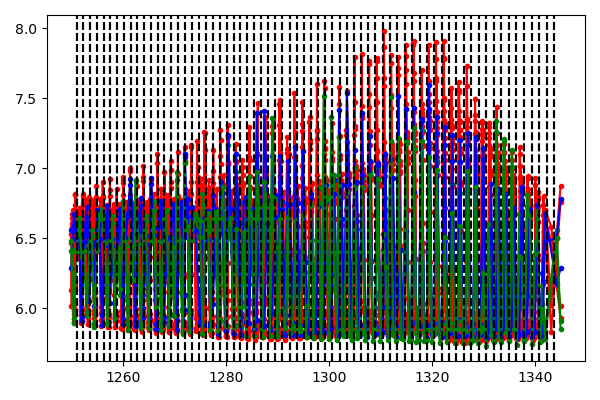

In [77]:
# For DAQ sweep

dir_name = "Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04"
fname ="Spectra_test_FFP_GS_step0.1nm_100us_NoDichroic_30dB_2025-11-06-19-31-51.h5"
fpath = os.path.join(data_dir, dir_name)
ds = load_data_from_file(fpath, fname)


dir_name = "Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04"
fname2 ="Spectra_test_FFP_GS_step0.5nm_100us_NoDichroic_30dB_2025-11-06-19-30-16.h5"
fpath2 = os.path.join(data_dir, dir_name)
ds2 = load_data_from_file(fpath2, fname2)

cal_pks = FFP_cal_pks["peaks"]
wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
wavset_sort = wavset_sort * u.nm

#restrict FFP_cal_pks to tuning range
FFP_cal = cal_pks[(cal_pks >= np.nanmin(ds['wavelength_set'])) & (cal_pks <= np.nanmax(ds['wavelength_set']))] 
FFP_cal = FFP_cal[~((FFP_cal > ds['wavelength_set'][0]) & (FFP_cal < ds['wavelength_set'][-1]))]

%matplotlib widget
fig, ax = plot_daqsweep_wavmon(ds, id_sweep_dir=False, colors=['r','k'])
fig, ax = plot_daqsweep_wavmon(ds2, id_sweep_dir=True, colors=['b','g'], ax=ax)



In [84]:
#id peaks on 0.1nm sweep

from scipy.signal import find_peaks

peak_wls = []

wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
wavset_sort = wavset_sort * u.nm
wavmon_arr = ds["VCSEL_wavmon_arr"][:, s_ind]

# print(wavmon_arr.shape)
# Find peaks in sweep unwrapped spectra, append wavelength of peaks to vector
for row in range(wavmon_arr.shape[0]):
    FFP_pks_ind, _ = find_peaks(wavmon_arr[row], distance=7, height=6.5)
    FFP_pks = wavset_sort[FFP_pks_ind]
    peak_wls.extend(FFP_pks.m)

print(peak_wls)
# FFP_pks, _ = find_peaks(ds['VCSEL_wavmon_raw'], distance=7, height=6.5)
# print(f"FFP_pks: {FFP_pks}")

# Plot histogram of id'd peaks

# reject peaks with few counts / xx std from peak norm


# for row in range(4):
#     if row %2 != 0:
#         ax.plot(wavset_sort, wavmon_arr[row], '.-', color=odd_color)
#     else:
#         ax.plot(wavset_sort, wavmon_arr[row], '.-', color=even_color)

# plt.figure(figsize=(4,3))
# plt.plot(ds['t'], ds['VCSEL_wavmon_raw'])
# plt.plot(ds['t'][FFP_pks], ds['VCSEL_wavmon_raw'][FFP_pks], 'x')
# plt.xlabel("Time (s)")
# plt.ylabel("wavmon")

[1250.7949937421777, 1252.2037546933666, 1253.5038798498122, 1254.7969962453064, 1256.0988735919898, 1257.5006257822279, 1258.7972465581977, 1260.1026282853566, 1261.3992490613266, 1262.6958698372964, 1263.9994993742177, 1264.7003754693367, 1265.4012515644556, 1266.1021276595745, 1267.3987484355441, 1268.099624530663, 1269.2981226533166, 1270.002503128911, 1270.7016270337922, 1271.9982478097622, 1273.3001251564456, 1274.4180225281602, 1275.188986232791, 1275.959949937422, 1276.7309136420524, 1277.4773466833542, 1278.9071339173968, 1279.664080100125, 1280.4210262828535, 1281.177972465582, 1281.9349186483105, 1283.266583229036, 1284.5982478097621, 1286.0700876095118, 1287.6120150187735, 1289.0137672090113, 1290.424280350438, 1291.8961201501877, 1293.3066332916144, 1294.8187734668334, 1296.1767209011261, 1297.6976220275342, 1299.1098873591989, 1300.6763454317897, 1302.0010012515643, 1303.4237797246556, 1304.9937421777222, 1306.4060075093869, 1307.8182728410513, 1309.3216520650813, 1310.71

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\scipy-1.14.1-py3.12-win-amd64.egg\scipy\signal\_peak_finding.py:266: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  value = np.asarray(value, order='C', dtype=np.float64)


loading file: Spectra_test_FFP_GS_step0.5nm_100us_60dB_2025-11-06-19-24-22.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...


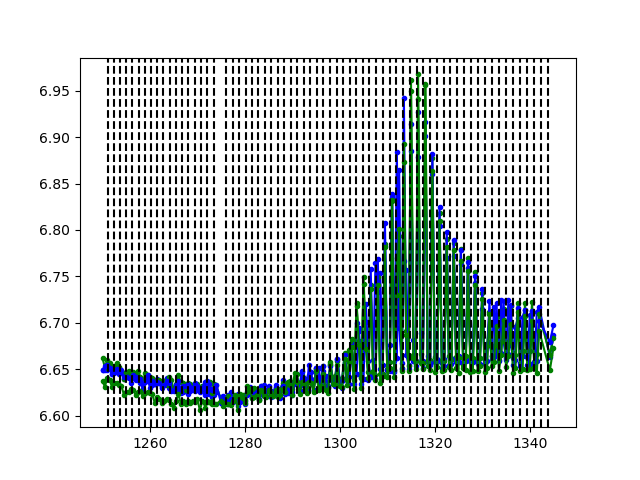

In [31]:
t_scan = ds["t_scan"]
t_sweep = ds["t_sweep"]
pad = 5
offset = 0
nx = ds['Vsrs_g'].shape[0]
ny = ds['Vsrs_g'].shape[1]

# d_spot = 1.8*u.um
# N = nx
# Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot)
pad_galvo_endpts = 1
# fixed_wav = 1074.4 * u.nm

# ΔVx = 0.516*u.V
# ΔVy = ΔVx

#Sort wavelength by ascending order and remove repeated values
# s_ind = np.argsort(wavelength_set)
# wavset_sort = wavelength_set[s_ind]
wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
wavset_sort = wavset_sort * u.nm

Vsrs_raw = ds['Dev2']['ai0']
HV_raw = Vmon_to_HVA(ds['Dev2']['ai1'])
VCSEL_wavmon_raw = ds['Dev2']['ai3']

#Remove padded samples at endpoints of daq2 arrays
Vsrs_raw = Vsrs_raw[pad:-pad]
HV_raw = HV_raw[pad:-pad]
VCSEL_wavmon_raw = VCSEL_wavmon_raw[pad:-pad]

#Reshape into 2d array with n_pix rows
num_pix = nx*ny 
npix = num_pix + 1
N_wav = Vsrs_raw.shape[0] // npix
N_unqwav = s_ind.shape[0]

print(f"npix: {npix}")
print(f"Vsrs_raw.shape[0]: {Vsrs_raw.shape[0]}")
print(f"N_wav: {N_wav}")
print(f"N_unqwav: {N_unqwav}")

Vsrs_pix = np.reshape(np.array(Vsrs_raw.to(u.V).m), (npix, N_wav))
HV_pix = np.reshape(np.array(HV_raw.to(u.V).m), (npix, N_wav))
VCSEL_wavmon_pix = np.reshape(np.array(VCSEL_wavmon_raw.to(u.V).m), (npix, N_wav))

#Discard 1st pixel sweep (first row) - galvo ai reads garbage here
#Discard pad_galvo_endpts points from the start of each row - vcsel ai lags ao
Vsrs_pix = Vsrs_pix[:-1,pad_galvo_endpts:]
HV_pix = HV_pix[:-1,pad_galvo_endpts:] 
VCSEL_wavmon_pix = VCSEL_wavmon_pix[:-1,pad_galvo_endpts:]


# Initialize arrays for pixel x spectra with sorted, unique spectral points
Vsrs_unqpix = np.zeros((num_pix, N_unqwav))
HV_unqpix = np.zeros((num_pix, N_unqwav))
VCSEL_wavmon_unqpix = np.zeros((num_pix, N_unqwav))

#Odd pixels are backward sweeps - flip (Assumes only 1 num_sweeps per pix is 1)
for row in range(Vsrs_pix.shape[0]):
    if row % 2 != 0:
        Vsrs_pix[row,:] = Vsrs_pix[row,::-1]
        HV_pix[row,:] = HV_pix[row,::-1]
        VCSEL_wavmon_pix[row,:] = VCSEL_wavmon_pix[row,::-1]
    # Sort columns (wavelength sweep) by ascending order and remove repeated values
    # Vsrs_unqpix[row,:] = Vsrs_pix[row, s_ind]
    # HV_unqpix[row,:] = HV_pix[row, s_ind]
    # VCSEL_wavmon_unqpix[row,:] = VCSEL_wavmon_pix[row, s_ind]
    
    
    

npix: 10001
Vsrs_raw.shape[0]: 2000200
N_wav: 200
N_unqwav: 190


NameError: name 'VCSEL_wavmon_pix' is not defined

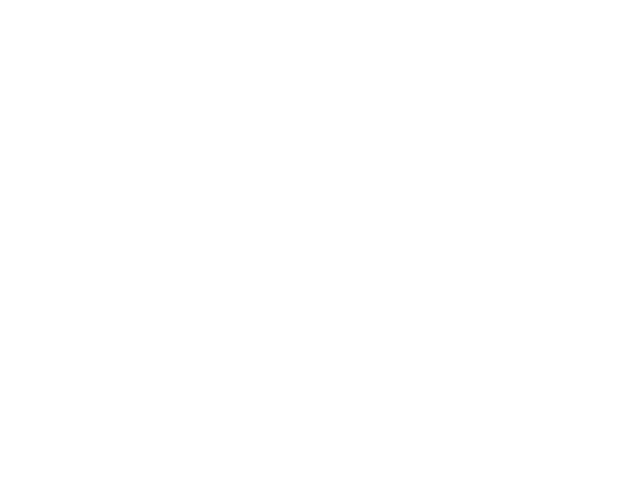

In [30]:
plt.figure()
# plt.plot(ds['t_sweep'], ds['Dev2']['ai3'])
for row in range(30):
    if row %2 != 0:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), VCSEL_wavmon_pix[row,:].T, '.-', color='g')
    else:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), VCSEL_wavmon_pix[row,:].T, '.-', color='b')
# plt.xlim((0,1))

plt.figure()
for row in range(31, 51):
    if row %2 != 0:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), Vsrs_pix[row,:].T, '.-', color = 'g')
    else:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), Vsrs_pix[row,:].T, '.-', color = 'b')

plt.figure()
for row in range(7000, 9000):
    if row %2 != 0:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), Vsrs_pix[row,:].T, '.-', color = 'g')
    else:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), Vsrs_pix[row,:].T, '.-', color = 'b')




In [776]:
ds["VCSEL_wavmon_pix"][0:2,:].shape

(2, 190)

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


(0.0, 0.4)

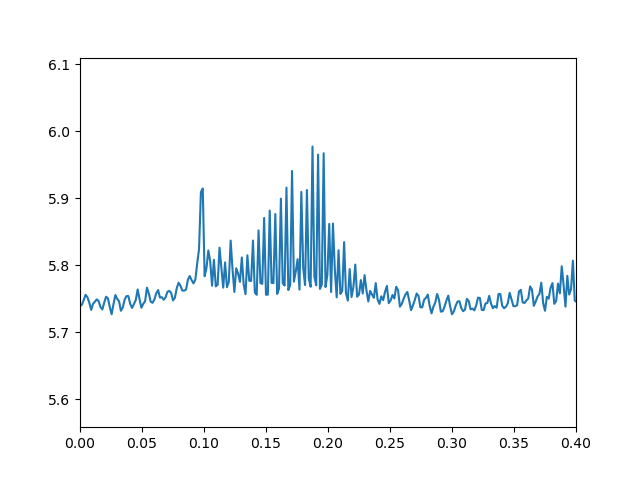

In [815]:
plt.figure()
plt.plot(ds['t_sweep'], ds['Dev2']['ai3'])
plt.xlim((0,0.4))

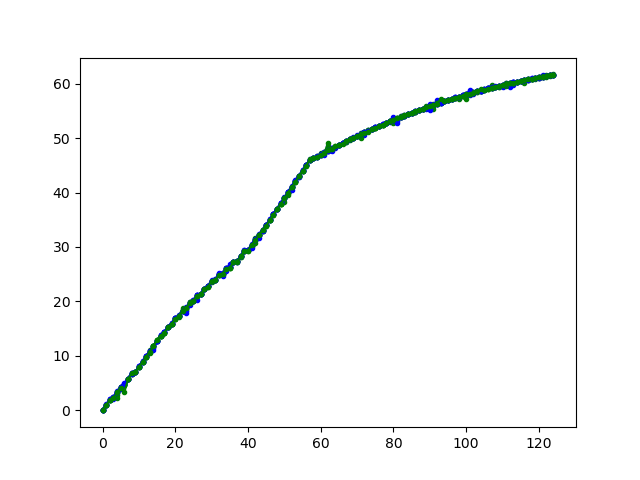

In [839]:
plt.figure()
for row in range(10000, 10010):
    if row %2 != 0:
        plt.plot(range(HV_pix.shape[1]), HV_pix[row,:].T, '.-', color = 'g')
    else:
        plt.plot(range(HV_pix.shape[1]), HV_pix[row,:].T, '.-', color = 'b')
